In [ ]:
import numpy as np
from glob import glob
import tensorflow as tf
from tensorflow import keras
from keras_unet_collection import models, utils
import os
import segmentation_models as sm
from segmentation_models import Unet
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.optimizers import Adam
import tensorflow.keras
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import AveragePooling2D, Flatten
from keras.layers import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model

In [3]:
x_train = np.load('MMHID/MMHID-train/MMHID-train-DG-imgs.npy')
y_train = np.load('MMHID/MMHID-train/MMHID-train-DG-labels.npy')
x_test = np.load('MMHID/MMHID-test/MMHID-test-DG-imgs.npy')
y_test = np.load('MMHID/MMHID-test/MMHID-test-DG-labels.npy')

In [4]:
keras.backend.set_image_data_format('channels_last')

In [ ]:
model = Unet(backbone_name='vgg16', encoder_weights=None, input_shape=(512, 512, 3))

In [6]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 512, 512, 64  1792        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 block1_conv2 (Conv2D)          (None, 512, 512, 64  36928       ['block1_conv1[0][0]']           
                                )                                                             

                                                                                                  
 decoder_stage0b_bn (BatchNorma  (None, 32, 32, 256)  1024       ['decoder_stage0b_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 decoder_stage0b_relu (Activati  (None, 32, 32, 256)  0          ['decoder_stage0b_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 decoder_stage1_upsampling (UpS  (None, 64, 64, 256)  0          ['decoder_stage0b_relu[0][0]']   
 ampling2D)                                                                                       
                                                                                                  
 decoder_s

 decoder_stage4a_conv (Conv2D)  (None, 512, 512, 16  4608        ['decoder_stage4_upsampling[0][0]
                                )                                ']                               
                                                                                                  
 decoder_stage4a_bn (BatchNorma  (None, 512, 512, 16  64         ['decoder_stage4a_conv[0][0]']   
 lization)                      )                                                                 
                                                                                                  
 decoder_stage4a_relu (Activati  (None, 512, 512, 16  0          ['decoder_stage4a_bn[0][0]']     
 on)                            )                                                                 
                                                                                                  
 decoder_stage4b_conv (Conv2D)  (None, 512, 512, 16  2304        ['decoder_stage4a_relu[0][0]']   
          

In [7]:
logdir = "ModelWeights/"
if not os.path.exists(logdir):
    os.mkdir(logdir)
    
output_model_file = os.path.join(logdir,'DG_Unet2_vgg16_100epochs.hdf5')

In [9]:
def lr_schedule(epoch):
    """Learning Rate Schedule

    Learning rate is scheduled to be reduced after 80, 120, 160, 180 epochs.
    Called automatically every epoch as part of callbacks during training.

    # Arguments
        epoch (int): The number of epochs

    # Returns
        lr (float32): learning rate
    """
    lr = 1e-3
    """if epoch >800:
        lr *= 1e-11
    elif epoch > 400:
        lr *= 1e-9
    elif epoch > 300:
        lr *= 1e-7
    elif epoch > 200:
        lr *= 1e-5
    elif epoch > 100:
        lr *= 1e-3"""
    print('Learning rate: ', lr)
    return lr

In [10]:
tensorboard = keras.callbacks.TensorBoard(logdir)
checkpoint = ModelCheckpoint(filepath=output_model_file,
                             monitor='loss',
                             verbose=1,
                             save_best_only=True)

lr_scheduler = LearningRateScheduler(lr_schedule)
lr_reducer = ReduceLROnPlateau(factor=np.sqrt(0.1),
                               cooldown=0,
                               patience=5,
                               min_lr=0.5e-6)

callbacks = [tensorboard, checkpoint, lr_reducer, lr_scheduler]#

In [11]:
model.compile(
    optimizer=Adam(learning_rate=lr_schedule(0)),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)


Learning rate:  0.001


In [ ]:
history=model.fit(
   x=x_train,
   y=y_train,
   batch_size=50,
   epochs=100,
   validation_split=0.4,
    callbacks=callbacks
)

In [14]:
model.load_weights(output_model_file)

In [ ]:
test = model.predict(x_test, batch_size=1, verbose=1)

In [16]:
model.evaluate(x_test,y_test) 

1/1 [==============================] - 18s 18s/step - loss: 0.1673 - accuracy: 0.9450


[0.16731815040111542, 0.9450167417526245]

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [18]:
from medpy import metric

def calculate_metric_percase(pred, gt):
    dice = metric.binary.dc(pred, gt)
    jc = metric.binary.jc(pred, gt)
    hd = metric.binary.hd95(pred, gt)
    asd = metric.binary.asd(pred, gt)
    return dice, jc, hd, asd


In [ ]:
calculate_metric_percase(test, y_test)

In [20]:
test[test>0.5]=1
test[test<0.5]=0

In [ ]:
calculate_metric_percase(test, y_test)

In [22]:
i=7

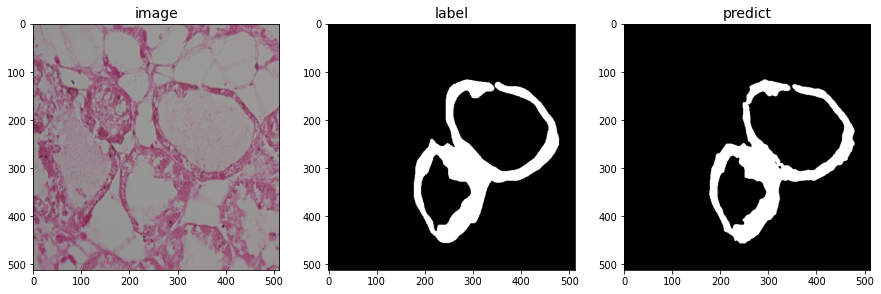

In [23]:
fig, axs = plt.subplots(1,3,figsize=(15,15))
axs[0].imshow(x_test[i], cmap ='gray')
axs[1].imshow(y_test[i], cmap ='gray')
axs[2].imshow(test[i], cmap ='gray')
axs[0].set_title("image",fontsize=14)
axs[1].set_title("label",fontsize=14)
axs[2].set_title("predict",fontsize=14)
plt.grid(False)

In [ ]:
test1 = tf.compat.v1.image.resize_images(test,(3000,4000))
test1.shape